### IMPORTS

In [1]:
import os
import numpy
import matplotlib.pyplot as plot
import seaborn
import pandas
import scipy.stats
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

### SET PARAMETERS

In [2]:
image_height = 224
image_width = 224
batch_size = 32
tta_steps = 5
saved_directory = "../saved"
test_directory = "../data/brain_tumor/testing"

### LOAD MODEL & CLASS NAMES

In [3]:
trained_model = load_model(os.path.join(saved_directory, "resnet_model.h5"))

with open(os.path.join(saved_directory, "class_names.json"), "r") as file_input:
    label_names = json.load(file_input)

### TEST DATA GENERATOR

In [4]:
test_augmenter = ImageDataGenerator(
    preprocessing_function=tensorflow.keras.applications.resnet50.preprocess_input)

tta_augmenter = ImageDataGenerator(
    preprocessing_function=tensorflow.keras.applications.resnet50.preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.1)

test_loader = test_augmenter.flow_from_directory(
    test_directory,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

true_labels = test_loader.classes

Found 1311 images belonging to 4 classes.


### REGULAR EVALUATION

/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


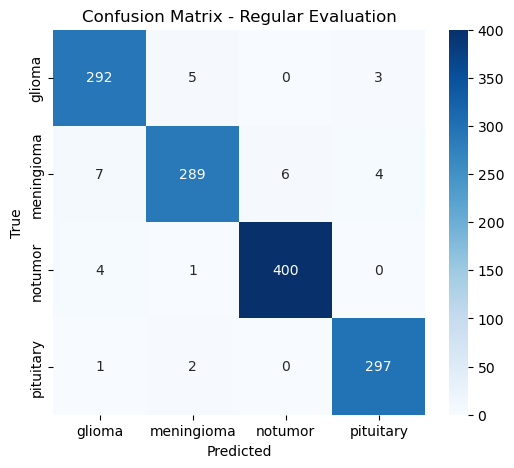

In [5]:
test_loader.reset()
predicted_probabilities = trained_model.predict(test_loader)
predicted_labels = numpy.argmax(predicted_probabilities, axis=1)

confusion_matrix_regular = confusion_matrix(true_labels, predicted_labels)

plot.figure(figsize=(6, 5))
seaborn.heatmap(
    confusion_matrix_regular,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names)
plot.xlabel("Predicted")
plot.ylabel("True")
plot.title("Confusion Matrix - Regular Evaluation")
plot.show()

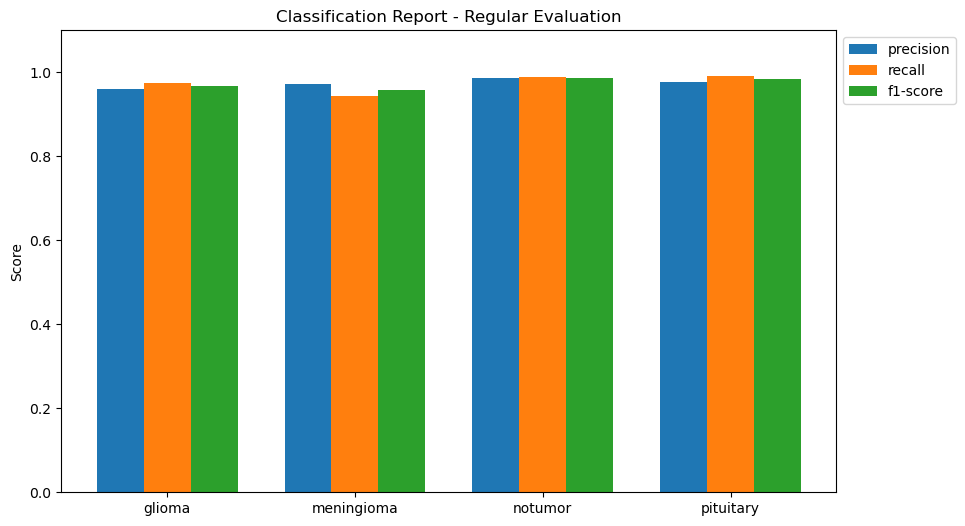

Classification Report - Regular Evaluation
              precision    recall  f1-score   support

      glioma       0.96      0.97      0.97       300
  meningioma       0.97      0.94      0.96       306
     notumor       0.99      0.99      0.99       405
   pituitary       0.98      0.99      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311

Accuracy - Regular Evaluation: 0.9748283752860412


In [6]:
report_regular = classification_report(true_labels, predicted_labels, target_names=label_names, output_dict=True)
classes = list(report_regular.keys())[:-3]
metrics = ['precision', 'recall', 'f1-score']

plot.figure(figsize=(10,6))
x = numpy.arange(len(classes))
width = 0.25
for i, metric in enumerate(metrics):
    plot.bar(x + (i-1)*width, [report_regular[c][metric] for c in classes], width, label=metric)
plot.xticks(x, classes)
plot.ylim(0,1.1)
plot.ylabel("Score")
plot.title("Classification Report - Regular Evaluation")
plot.legend(loc='upper left', bbox_to_anchor=(1, 1))
plot.show()

print("Classification Report - Regular Evaluation")
print(classification_report(true_labels, predicted_labels, target_names=label_names))
print("Accuracy - Regular Evaluation:", accuracy_score(true_labels, predicted_labels))

### TTA (TEST TIME AUGMENTATION) EVALUATION

TTA Step 1/5
Found 1311 images belonging to 4 classes.


/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


TTA Step 2/5
Found 1311 images belonging to 4 classes.
TTA Step 3/5
Found 1311 images belonging to 4 classes.
TTA Step 4/5
Found 1311 images belonging to 4 classes.
TTA Step 5/5
Found 1311 images belonging to 4 classes.


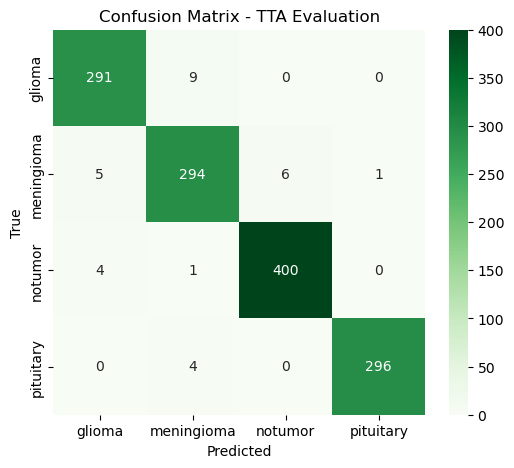

In [7]:
prediction_list = []

for step_index in range(tta_steps):
    print(f'TTA Step {step_index + 1}/{tta_steps}')
    tta_loader = tta_augmenter.flow_from_directory(
        test_directory,
        target_size=(image_height, image_width),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False)
    prediction_list.append(trained_model.predict(tta_loader, verbose=0))

tta_predictions = numpy.mean(prediction_list, axis=0)
predicted_labels_tta = numpy.argmax(tta_predictions, axis=1)

confusion_matrix_tta = confusion_matrix(true_labels, predicted_labels_tta)

plot.figure(figsize=(6, 5))
seaborn.heatmap(
    confusion_matrix_tta,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_names,
    yticklabels=label_names)
plot.xlabel('Predicted')
plot.ylabel('True')
plot.title('Confusion Matrix - TTA Evaluation')
plot.show()

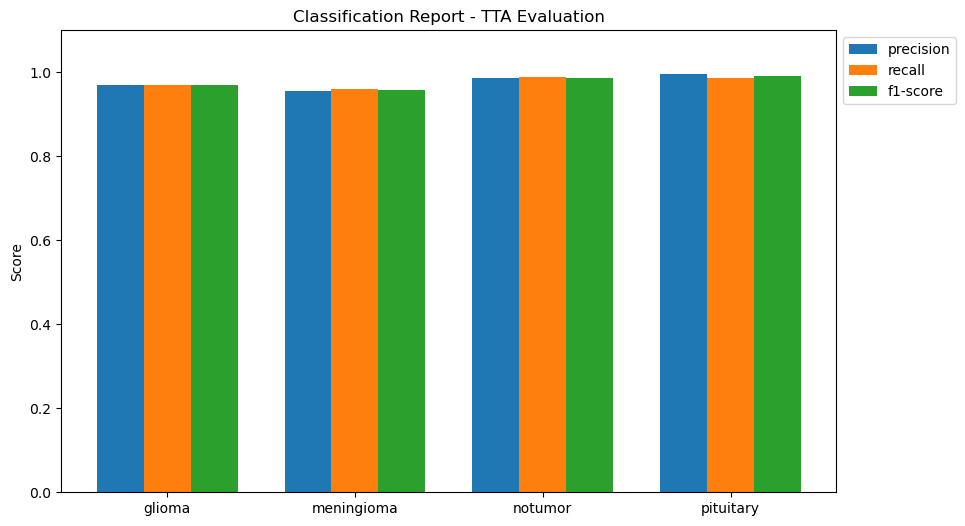

Classification Report - TTA Evaluation
              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97       300
  meningioma       0.95      0.96      0.96       306
     notumor       0.99      0.99      0.99       405
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311

Accuracy - TTA Evaluation: 0.977116704805492


In [8]:
report_tta = classification_report(true_labels, predicted_labels_tta, target_names=label_names, output_dict=True)
classes = list(report_tta.keys())[:-3]
metrics = ['precision', 'recall', 'f1-score']

plot.figure(figsize=(10,6))
x = numpy.arange(len(classes))
width = 0.25
for i, metric in enumerate(metrics):
    plot.bar(x + (i-1)*width, [report_tta[c][metric] for c in classes], width, label=metric)
plot.xticks(x, classes)
plot.ylim(0,1.1)
plot.ylabel("Score")
plot.title("Classification Report - TTA Evaluation")
plot.legend(loc='upper left', bbox_to_anchor=(1, 1))
plot.show()

print("Classification Report - TTA Evaluation")
print(classification_report(true_labels, predicted_labels_tta, target_names=label_names))
print("Accuracy - TTA Evaluation:", accuracy_score(true_labels, predicted_labels_tta))

### SAVE OUTPUTS

In [9]:
test_loader.reset()
final_probs = trained_model.predict(test_loader)
final_preds = numpy.argmax(final_probs, axis=1)

file_paths = [os.path.join(test_directory, f) for f in test_loader.filenames]
true_class_names = [label_names[t] for t in true_labels]
pred_class_names = [label_names[p] for p in final_preds]

entropy_values = -numpy.sum(
    final_probs * numpy.log(final_probs + 1e-10), axis=1)

results_df = pandas.DataFrame({
    'file': file_paths,
    'true': true_class_names,
    'pred': pred_class_names,
    'entropy': entropy_values})

results_df.to_csv(os.path.join(saved_directory, 'results_dataframe.csv'), index=False)
numpy.save(os.path.join(saved_directory, 'final_preds.npy'), final_probs)

print('Saved results_dataframe.csv and final_preds.npy')
print(f'Total images: {len(results_df)}')
print(f'Correct predictions: {(results_df["true"] == results_df["pred"]).sum()}')
print(f'Accuracy: {(results_df["true"] == results_df["pred"]).mean():.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step
Saved results_dataframe.csv and final_preds.npy
Total images: 1311
Correct predictions: 1278
Accuracy: 0.9748
